In [8]:
# Install required packages (if needed)
# !pip3 install pandas numpy matplotlib seaborn scikit-learn tqdm requests -q

# Ollama API setup and imports
import requests
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import json
import time
from tqdm import tqdm
from sklearn.metrics import accuracy_score, f1_score, matthews_corrcoef, precision_score, recall_score, confusion_matrix, classification_report
import numpy as np
from datetime import datetime
import re

print("✓ Libraries imported successfully")
print("✓ Ollama will be used for LLM inference (local)")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)

# Ollama API configuration
OLLAMA_API_URL = "http://localhost:11434/api/generate"

✓ Libraries imported successfully
✓ Ollama will be used for LLM inference (local)


## 1. Load Dataset

In [9]:
# Load the 100% agreement dataset (highest quality)
data_path = "../../../Startified Data PMP/Processed Data/processed_data.csv"

df = pd.read_csv(data_path)
df.rename(columns={"sentiment": "true_insight"}, inplace=True)
df.rename(columns={"sentences": "sentence"}, inplace=True)

print(f"Dataset loaded: {len(df)} sentences")

# Display sample
print("\n" + "=" * 80)
print("Sample sentences:")
print("=" * 80)
display(df.sample(5, random_state=42))

Dataset loaded: 210 sentences

Sample sentences:


,sentence,true_insight,word_count,char_length
30,Tallink Silja attributes the significant drop ...,negative,46,267
172,"ADP News - Feb 13 , 2009 - Finnish retailer Ke...",negative,43,207
84,20 October 2010 - Finnish environmental manage...,negative,43,237
199,"Finnair 's Tallinn-based subsidiary , Aero AS ...",negative,31,178
60,MegaFon 's subscriber base increased 16.1 % in...,positive,50,246


## 2. Tree-of-Thought Prompt Design

**Multi-Path Reasoning**:
- Path 1: Consider "positive" hypothesis
- Path 2: Consider "negative" hypothesis  
- Path 3: Consider "neutral" hypothesis
- Evaluation: Score each path's evidence strength
- Selection: Choose the most supported hypothesis

In [10]:
def create_tot_prompt(sentence):
    """
    Creates an advanced Tree-of-Thought prompt that forces 
    comparative deliberation and conflict resolution.
    """
    prompt = f"""You are a panel of three Senior Investment Strategists deliberating on a financial statement.

Financial Statement:
"{sentence}"

Task: Critically evaluate the statement through three competing perspectives to determine the net investor insight.

---
STEP 1: ARGUMENT FOR POSITIVE (Bull Case)
- Identify all growth metrics, margin expansions, or efficiency gains.
- What is the best-case scenario for an investor here?

STEP 2: ARGUMENT FOR NEGATIVE (Bear Case)
- Identify all risks, declining trends, or hidden costs.
- Why might a cautious investor view this as a red flag?

STEP 3: COMPARATIVE EVALUATION (Synthesis)
- Weigh Step 1 against Step 2. 
- Is the positive news "priced in" or outweighed by the negative? 
- Determine if the net impact is significant enough to move the needle beyond "Neutral."

---
FINAL DECISION:
Based on the synthesis of all three steps, provide the final classification.

Return ONLY strictly JSON in this format:
{{
    "insight": "positive/negative/neutral",
    "confidence": 0.0-1.0,
    "rationale": "Contrast the winning argument against the losing arguments (e.g., 'While revenue grew, the decline in margins is the primary driver of value erosion.')"
}}
"""
    return prompt

# Test prompt
print("=" * 80)
print("TREE-OF-THOUGHT PROMPT EXAMPLE")
print("=" * 80)
print(create_tot_prompt(df.iloc[0]["sentence"]))

TREE-OF-THOUGHT PROMPT EXAMPLE
You are a panel of three Senior Investment Strategists deliberating on a financial statement.

Financial Statement:
"Supported Nokia phones include : N96 , N95-8GB , N95 , N93-N931 , N92 , N85 , N82 , N81 , N80 , N79 , N78 , N77 , N76 , N75 , N73 , N72 , N71 , E90 , E71 , E70 , E66 , E65 , E62 , E61-E61i , E60 , E51 , E50 , Touch Xpress 5800 , 6220 Classic , 6210 Navigator , 6120 Classic , 6110 Navigator , 5700 , 5500 , 5320XM ."

Task: Critically evaluate the statement through three competing perspectives to determine the net investor insight.

---
STEP 1: ARGUMENT FOR POSITIVE (Bull Case)
- Identify all growth metrics, margin expansions, or efficiency gains.
- What is the best-case scenario for an investor here?

STEP 2: ARGUMENT FOR NEGATIVE (Bear Case)
- Identify all risks, declining trends, or hidden costs.
- Why might a cautious investor view this as a red flag?

STEP 3: COMPARATIVE EVALUATION (Synthesis)
- Weigh Step 1 against Step 2. 
- Is the pos

## 3. Model Inference Functions

In [11]:
def call_ollama(prompt, model_name, temperature=0.0):
    """Call Ollama API for LLM inference"""
    max_retries = 3
    last_error = None
    
    for attempt in range(max_retries):
        try:
            response = requests.post(
                OLLAMA_API_URL,
                json={
                    "model": model_name,
                    "prompt": prompt,
                    "stream": False,
                    "temperature": temperature,
                },
                timeout=150,
            )
            
            if response.status_code == 200:
                result = response.json()
                return result.get("response", "")
            else:
                last_error = f"HTTP {response.status_code}"
                
        except Exception as e:
            last_error = str(e)
            if attempt < max_retries - 1:
                time.sleep(2 ** attempt)
                continue
            return None
    
    return None


import json
import re

REQUIRED_KEYS = {"insight", "confidence", "rationale"}
VALID_INSIGHT_VALUES = {"positive", "negative", "neutral"}

def parse_response(response_text):
    """Parse JSON response from model"""
    try:
        if "```json" in response_text:
            json_str = response_text.split("```json")[1].split("```")[0].strip()
        elif "```" in response_text:
            json_str = response_text.split("```")[1].strip()
        else:
            json_str = response_text.strip()

        # Find the first { ... } block in case there's leading text
        start = json_str.find("{")
        end = json_str.rfind("}") + 1
        if start != -1 and end > start:
            json_str = json_str[start:end]

        result = json.loads(json_str)

        # If model returned a list, take the first element
        if isinstance(result, list):
            result = result[0]

        # Validate only the 3 required keys exist and insight is valid
        if not REQUIRED_KEYS.issubset(result.keys()):
            raise ValueError(f"Missing required keys. Got: {set(result.keys())}")
        if result["insight"] not in VALID_INSIGHT_VALUES:
            raise ValueError(f"Invalid insight value: {result['insight']}")

        # Return only the 3 keys, stripping any extra fields like "company"
        return {k: result[k] for k in REQUIRED_KEYS}

    except Exception as e:
        print("Parse error: {}".format(str(e)[:100]))
        print("Raw response was:\n{}".format(response_text))
        response_lower = response_text.lower() if response_text else ""
        if "positive" in response_lower and "negative" not in response_lower:
            return {"insight": "positive", "confidence": 0.5, "rationale": "Parsed from text"}
        elif "negative" in response_lower:
            return {"insight": "negative", "confidence": 0.5, "rationale": "Parsed from text"}
        elif "neutral" in response_lower:
            return {"insight": "neutral", "confidence": 0.5, "rationale": "Parsed from text"}
        return None

print("✓ Inference functions defined")

✓ Inference functions defined


## 4. Run Experiments

In [12]:
# Run on sample dataset for faster iteration and debugging

def run_tot_experiment(df, model_name, exp_id):
    print(f"Running {exp_id}: {model_name} (ToT)...")
    results = []
    
    # Ensure dataframe has the correct insight column name
    true_col = "true_insight" if "true_insight" in df.columns else "true_sentiment"

    for idx, row in tqdm(df.iterrows(), total=len(df), desc=f"{exp_id} Progress"):
        prompt = create_tot_prompt(row["sentence"])
        response = call_ollama(prompt, model_name)
        
        if response:
            parsed = parse_response(response)
            results.append({
                "sentence": row["sentence"],
                "true_insight": row[true_col],
                "predicted_insight": parsed.get("insight", "error") if parsed else "error",
                "confidence": parsed.get("confidence", 0) if parsed else 0,
                "rationale": parsed.get("rationale", "Parse error") if parsed else "Parse error"
            })
        time.sleep(0.1)
    return pd.DataFrame(results)

In [13]:
# Execution of I10
i10_df = run_tot_experiment(df, "llama3.1:8b", "I10")

Running I10: llama3.1:8b (ToT)...


I10 Progress:  73%|███████▎  | 154/210 [40:12<17:05, 18.31s/it] 

Parse error: Extra data: line 7 column 1 (char 330)
Raw response was:
{
    "insight": "negative",
    "confidence": 0.75,
    "rationale": "The net loss of $59.3 million and decline from a net profit to a net loss is a significant red flag. While there may be some growth metrics or efficiency gains, the negative impact on the company's bottom line appears to outweigh any potential positives."
}

**Step 1: Argument for Positive (Bull Case)**

* The statement mentions that "real estate companies are experiencing a resurgence" in certain markets.
* However, upon closer inspection, this is not explicitly mentioned in the provided financial statement. It appears to be an external assumption rather than a data-driven conclusion.

**Step 2: Argument for Negative (Bear Case)**

* The company has posted a net loss of $59.3 million compared to a net profit of $31 million in the corresponding quarter of 2007.
* This significant decline from profitability to a net loss is a major concern and sugg

I10 Progress: 100%|██████████| 210/210 [52:27<00:00, 14.99s/it]


In [14]:
print("\nI10 Sample Results:")
print("\nTrue insight Counts:")
print(i10_df['true_insight'].value_counts())
print("\nPredicted insight Counts:")
print(i10_df['predicted_insight'].value_counts())


I10 Sample Results:

True insight Counts:
true_insight
neutral     70
negative    70
positive    70
Name: count, dtype: int64

Predicted insight Counts:
predicted_insight
negative    86
neutral     65
positive    59
Name: count, dtype: int64


In [28]:
#update i10, df value where predicted insight is positive/negative/neutral to match neutral
i10_df['predicted_insight'] = i10_df['predicted_insight'].apply(lambda x: 'neutral' if x in ['positive/negative/neutral'] else x)
print("\nTrue insight Counts:")
print(i10_df['true_insight'].value_counts())
print("\nPredicted insight Counts:")
print(i10_df['predicted_insight'].value_counts())


True insight Counts:
true_insight
neutral     70
negative    70
positive    70
Name: count, dtype: int64

Predicted insight Counts:
predicted_insight
negative    86
neutral     65
positive    59
Name: count, dtype: int64


In [16]:
#Execution of I11
i11_df = run_tot_experiment(df, "qwen3:8b", "I11")

Running I11: qwen3:8b (ToT)...


I11 Progress: 100%|██████████| 210/210 [3:32:53<00:00, 60.83s/it]   


In [17]:
print("\nI11 Sample Results:")
print("\nTrue insight Counts:")
print(i11_df['true_insight'].value_counts())
print("\nPredicted insight Counts:")
print(i11_df['predicted_insight'].value_counts())


I11 Sample Results:

True insight Counts:
true_insight
neutral     70
negative    70
positive    70
Name: count, dtype: int64

Predicted insight Counts:
predicted_insight
neutral     123
negative     70
positive     17
Name: count, dtype: int64


In [18]:
# Execution of I12
i12_df = run_tot_experiment(df, "deepseek-r1:8b", "I12")

Running I12: deepseek-r1:8b (ToT)...


I12 Progress: 100%|██████████| 210/210 [2:26:02<00:00, 41.72s/it]  


In [19]:
print("\nI12 Sample Results:")
print("\nTrue insight Counts:")
print(i12_df['true_insight'].value_counts())
print("\nPredicted insight Counts:")
print(i12_df['predicted_insight'].value_counts())


I12 Sample Results:

True insight Counts:
true_insight
neutral     70
negative    70
positive    70
Name: count, dtype: int64

Predicted insight Counts:
predicted_insight
neutral     144
negative     63
positive      3
Name: count, dtype: int64


## 5. Calculate Metrics

In [20]:
# Calculate metrics for all experiments
def calculate_metrics(df, exp_name):
    """Calculate all evaluation metrics"""
    if df.empty or "predicted_insight" not in df.columns:
        print(f"⚠️ Warning: {exp_name} has no valid predictions!")
        return (
            {
                "Experiment": exp_name,
                "Total Samples": 0,
                "Valid Predictions": 0,
                "Accuracy": 0,
                "Macro-F1": 0,
                "Weighted-F1": 0,
                "Macro-Precision": 0,
                "Macro-Recall": 0,
                "MCC": 0,
                "Positive_Precision": 0,
                "Positive_Recall": 0,
                "Positive_F1": 0,
                "Negative_Precision": 0,
                "Negative_Recall": 0,
                "Negative_F1": 0,
                "Neutral_Precision": 0,
                "Neutral_Recall": 0,
                "Neutral_F1": 0,
            },
            np.zeros((3, 3)),
            pd.DataFrame(),
        )
    
    valid_df = df[
        df["predicted_insight"].isin(["positive", "negative", "neutral"])
    ].copy()
    if valid_df.empty:
        print(f"⚠️ Warning: {exp_name} has no valid predictions after filtering!")
        return (
            {
                "Experiment": exp_name,
                "Total Samples": len(df),
                "Valid Predictions": 0,
                "Accuracy": 0,
                "Macro-F1": 0,
                "Weighted-F1": 0,
                "Macro-Precision": 0,
                "MCC": 0,
                "Positive_Precision": 0,
                "Positive_Recall": 0,
                "Positive_F1": 0,
                "Negative_Precision": 0,
                "Negative_Recall": 0,
                "Negative_F1": 0,
                "Neutral_Precision": 0,
                "Neutral_Recall": 0,
                "Neutral_F1": 0,
            },
            np.zeros((3, 3)),
            pd.DataFrame(),
        )
    y_true = valid_df["true_insight"]
    y_pred = valid_df["predicted_insight"]
    
    metrics = {
        "Experiment": exp_name,
        "Total Samples": len(df),
        "Valid Predictions": len(valid_df),
        "Accuracy": accuracy_score(y_true, y_pred),
        "Macro-F1": f1_score(y_true, y_pred, average="macro"),
        "Weighted-F1": f1_score(y_true, y_pred, average="weighted"),
        "Macro-Precision": precision_score(y_true, y_pred, average="macro"),
        "Macro-Recall": recall_score(y_true, y_pred, average="macro"),
        "MCC": matthews_corrcoef(y_true, y_pred),
    }
    
    labels = ["positive", "negative", "neutral"]
    precision_per_class = precision_score(
        y_true, y_pred, labels=labels, average=None, zero_division=0
    )
    recall_per_class = recall_score(
        y_true, y_pred, labels=labels, average=None, zero_division=0
    )
    f1_per_class = f1_score(
        y_true, y_pred, labels=labels, average=None, zero_division=0
    )

    for i, label in enumerate(labels):
        metrics[f"{label.capitalize()}_Precision"] = precision_per_class[i]
        metrics[f"{label.capitalize()}_Recall"] = recall_per_class[i]
        metrics[f"{label.capitalize()}_F1"] = f1_per_class[i]

    cm = confusion_matrix(y_true, y_pred, labels=labels)
    return metrics, cm, valid_df


# Calculate metrics for all experiments
i10_metrics, i10_cm, i10_valid = calculate_metrics(i10_df, "I10: Llama3.1:8b (ToT)")
i11_metrics, i11_cm, i11_valid = calculate_metrics(i11_df, "I11: Qwen3:8b (ToT)")
i12_metrics, i12_cm, i12_valid = calculate_metrics(i12_df, "I12: DeepSeek-R1:8b (ToT)")

metrics_df = pd.DataFrame([i10_metrics, i11_metrics, i12_metrics])
print("\n" + "=" * 80)
print("CHAIN-OF-THOUGHT PERFORMANCE COMPARISON")
print("=" * 80)
display(
    metrics_df[
        ["Experiment", "Accuracy", "Macro-F1", "Macro-Precision", "Macro-Recall"]
    ].round(4)
)


CHAIN-OF-THOUGHT PERFORMANCE COMPARISON


,Experiment,Accuracy,Macro-F1,Macro-Precision,Macro-Recall
0,I10: Llama3.1:8b (ToT),0.6857,0.6823,0.6884,0.6857
1,I11: Qwen3:8b (ToT),0.6667,0.6262,0.7473,0.6667
2,I12: DeepSeek-R1:8b (ToT),0.6000,0.5206,0.7907,0.6000


## 6. Visualize Results

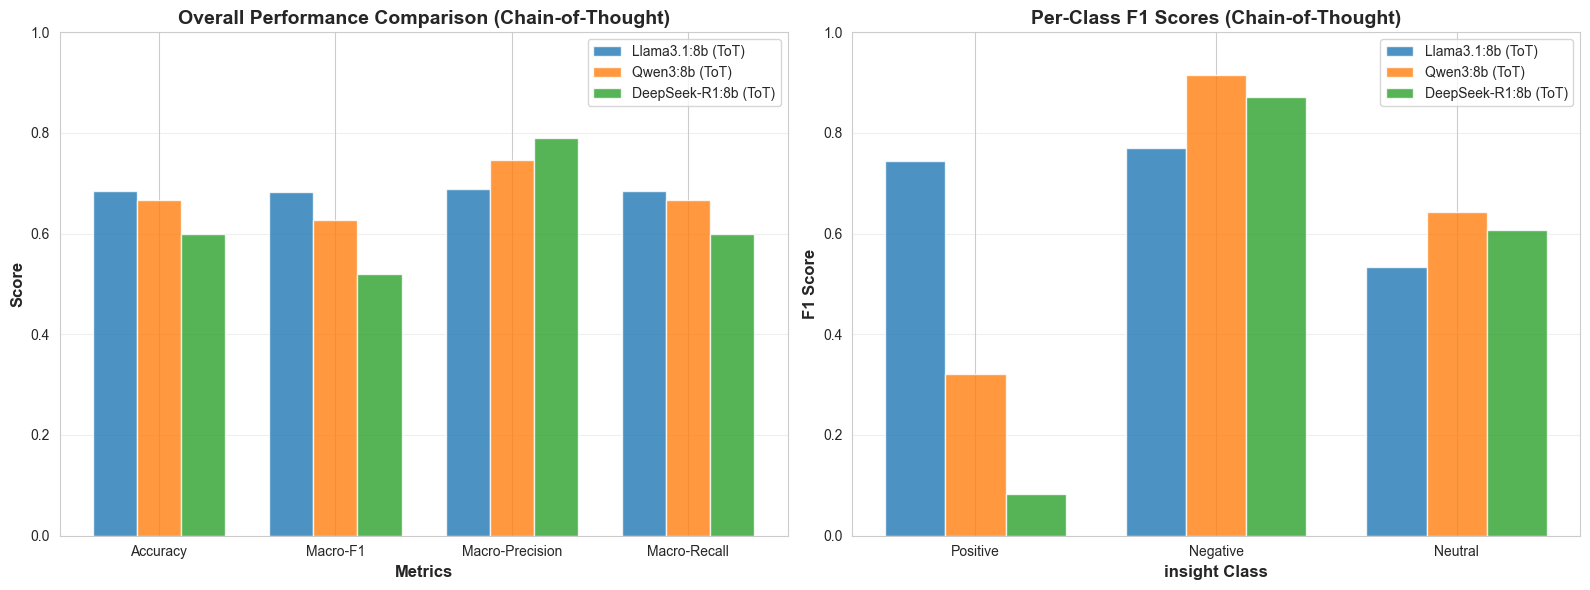

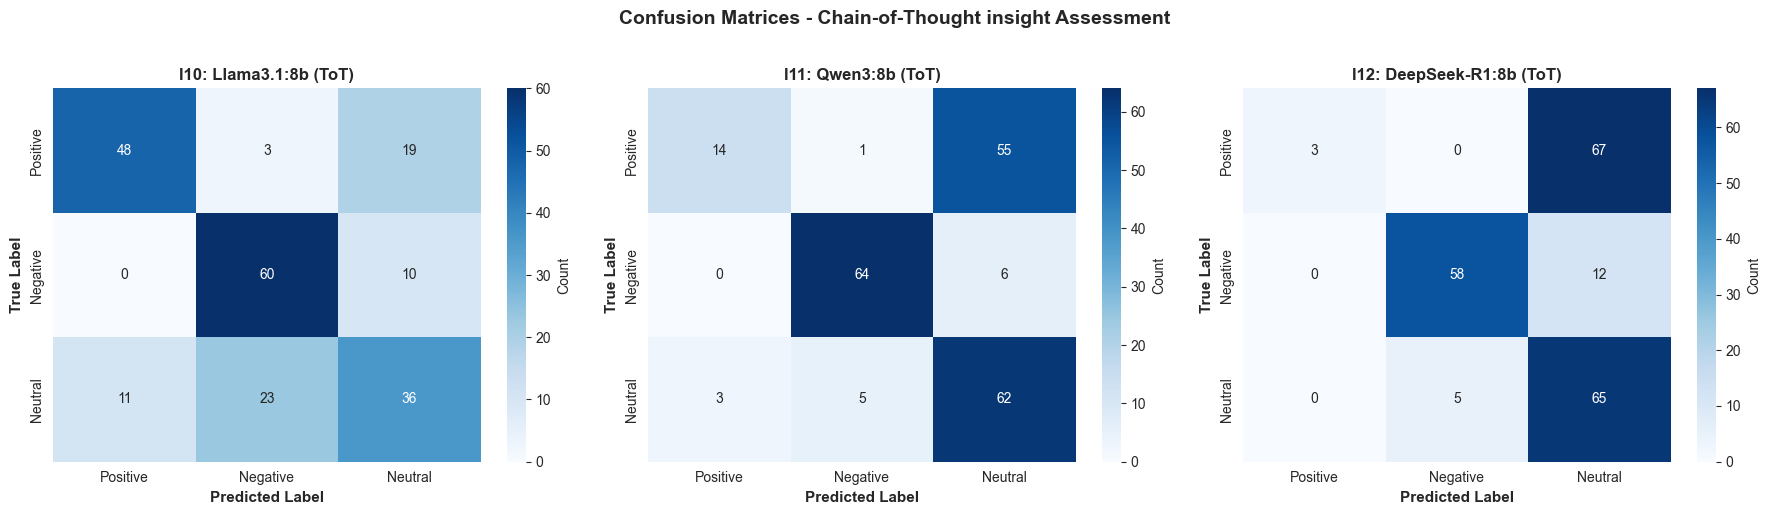

In [21]:
# Performance comparison bar chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Overall metrics
metrics_to_plot = ["Accuracy", "Macro-F1", "Macro-Precision", "Macro-Recall"]
x = np.arange(len(metrics_to_plot))
width = 0.25

for i, (metrics, label) in enumerate(
    [
        (i10_metrics, "Llama3.1:8b (ToT)"),
        (i11_metrics, "Qwen3:8b (ToT)"),
        (i12_metrics, "DeepSeek-R1:8b (ToT)"),
    ]
):
    values = [np.nan_to_num(metrics.get(m, 0.0)) for m in metrics_to_plot]
    axes[0].bar(x + i * width, values, width, label=label, alpha=0.8)

axes[0].set_xlabel("Metrics", fontsize=12, weight="bold")
axes[0].set_ylabel("Score", fontsize=12, weight="bold")
axes[0].set_title(
    "Overall Performance Comparison (Chain-of-Thought)", fontsize=14, weight="bold"
)
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(metrics_to_plot)
axes[0].legend()
axes[0].set_ylim([0, 1])
axes[0].grid(axis="y", alpha=0.3)

# Per-class F1 scores
classes = ["Positive", "Negative", "Neutral"]
x2 = np.arange(len(classes))

for i, (metrics, label) in enumerate(
    [
        (i10_metrics, "Llama3.1:8b (ToT)"),
        (i11_metrics, "Qwen3:8b (ToT)"),
        (i12_metrics, "DeepSeek-R1:8b (ToT)"),
    ]
):
    values = [metrics[f"{c}_F1"] for c in classes]
    axes[1].bar(x2 + i * width, values, width, label=label, alpha=0.8)

axes[1].set_xlabel("insight Class", fontsize=12, weight="bold")
axes[1].set_ylabel("F1 Score", fontsize=12, weight="bold")
axes[1].set_title("Per-Class F1 Scores (Chain-of-Thought)", fontsize=14, weight="bold")
axes[1].set_xticks(x2 + width)
axes[1].set_xticklabels(classes)
axes[1].legend()
axes[1].set_ylim([0, 1])
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("tot_performance_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
labels = ["Positive", "Negative", "Neutral"]

for idx, (cm, title) in enumerate(
    [
        (i10_cm, "I10: Llama3.1:8b (ToT)"),
        (i11_cm, "I11: Qwen3:8b (ToT)"),
        (i12_cm, "I12: DeepSeek-R1:8b (ToT)"),
    ]
):
    sns.heatmap(
        cm,
        annot=True,
        
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
        ax=axes[idx],
        cbar_kws={"label": "Count"},
    )
    axes[idx].set_title(title, fontsize=12, weight="bold")
    axes[idx].set_ylabel("True Label", fontsize=11, weight="bold")
    axes[idx].set_xlabel("Predicted Label", fontsize=11, weight="bold")

plt.suptitle(
    "Confusion Matrices - Chain-of-Thought insight Assessment",
    fontsize=14,
    weight="bold",
    y=1.02,
)
plt.tight_layout()
plt.savefig("tot_confusion_matrices.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. Save Results

In [22]:
# Save detailed results
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

i10_df.to_csv(f"i10_llama3.1_8b_ToT_{timestamp}.csv", index=False)
i11_df.to_csv(f"i11_qwen3_8b_ToT_{timestamp}.csv", index=False)
i12_df.to_csv(f"i12_deepseek_r1_8b_ToT_{timestamp}.csv", index=False)

# Save metrics summary
metrics_df.to_csv(f"tot_metrics_summary_{timestamp}.csv", index=False)

print(f"\n✓ Chain-of-Thought results saved with timestamp: {timestamp}")
print("\nFiles created:")
print(f"  - i10_llama3.1_8b_ToT_{timestamp}.csv")
print(f"  - i11_qwen3_8b_ToT_{timestamp}.csv")
print(f"  - i12_deepseek_r1_8b_ToT_{timestamp}.csv")
print(f"  - ToT_metrics_summary_{timestamp}.csv")
print(f"  - ToT_performance_comparison.png")
print(f"  - ToT_confusion_matrices.png")


✓ Chain-of-Thought results saved with timestamp: 20260227_065230

Files created:
  - i10_llama3.1_8b_ToT_20260227_065230.csv
  - i11_qwen3_8b_ToT_20260227_065230.csv
  - i12_deepseek_r1_8b_ToT_20260227_065230.csv
  - ToT_metrics_summary_20260227_065230.csv
  - ToT_performance_comparison.png
  - ToT_confusion_matrices.png


## 8. Error Analysis

In [23]:
# Error Analysis: Most Common Misclassifications
print("=" * 80)
print("ERROR ANALYSIS: CHAIN-OF-THOUGHT MISCLASSIFICATION PATTERNS")
print("=" * 80)

for df_result, exp_name in [
    (i10_valid, "I10: Llama3.1:8b"),
    (i11_valid, "I11: Qwen3:8b"),
    (i12_valid, "I12: DeepSeek-R1:8b"),
]:
    print(f"\n{exp_name}")
    print("-" * 80)

    # Identify errors
    errors = df_result[df_result["true_insight"] != df_result["predicted_insight"]]

    # Count error types
    error_types = (
        errors.groupby(["true_insight", "predicted_insight"])
        .size()
        .reset_index(name="count")
    )
    error_types = error_types.sort_values("count", ascending=False)

    print(
        f"\nTotal Errors: {len(errors)} / {len(df_result)} ({len(errors) / len(df_result) * 100:.2f}%)"
    )
    print("\nMost Common Error Types:")
    display(error_types.head(5))

    # Show examples of worst errors (high confidence, wrong prediction)
    if len(errors) > 0:
        worst_errors = errors.nlargest(3, "confidence")
        print(f"\nTop 3 High-Confidence Errors:")
        for idx, row in worst_errors.iterrows():
            print(
                f"\n  True: {row['true_insight']} | Predicted: {row['predicted_insight']} | Conf: {row['confidence']:.2f}"
            )
            print(f"  Sentence: {row['sentence'][:120]}...")
            print(f"  Rationale: {row['rationale']}")

# Class-wise Performance Comparison
print("\n" + "=" * 80)
print("CLASS-WISE PERFORMANCE BREAKDOWN")
print("=" * 80)

class_comparison = []
for metrics, model_name in [
    (i10_metrics, "Llama3.1:8b"),
    (i11_metrics, "Qwen3:8b"),
    (i12_metrics, "DeepSeek-R1:8b"),
]:
    for insight in ["Positive", "Negative", "Neutral"]:
        class_comparison.append(
            {
                "Model": model_name,
                "Class": insight,
                "Precision": metrics[f"{insight}_Precision"],
                "Recall": metrics[f"{insight}_Recall"],
                "F1-Score": metrics[f"{insight}_F1"],
            }
        )

class_df = pd.DataFrame(class_comparison)

# Pivot for better visualization
for metric in ["Precision", "Recall", "F1-Score"]:
    print(f"\n{metric} by Class:")
    pivot = class_df.pivot(index="Class", columns="Model", values=metric)
    display(pivot.round(4))

print("\n" + "=" * 80)
print("COMPREHENSIVE METRICS TABLE")
print("=" * 80)
display(metrics_df.round(4))

ERROR ANALYSIS: CHAIN-OF-THOUGHT MISCLASSIFICATION PATTERNS

I10: Llama3.1:8b
--------------------------------------------------------------------------------

Total Errors: 66 / 210 (31.43%)

Most Common Error Types:


,true_insight,predicted_insight,count
1,neutral,negative,23
4,positive,neutral,19
2,neutral,positive,11
0,negative,neutral,10
3,positive,negative,3



Top 3 High-Confidence Errors:

  True: neutral | Predicted: negative | Conf: 0.85
  Sentence: The company serves customers in various industries , including process and resources , industrial machinery , architectu...
  Rationale: While the company's diversification presents some opportunities for growth, its lack of focus and specialization raises significant concerns about its ability to compete effectively in any one sector, outweighing any potential benefits.

  True: neutral | Predicted: positive | Conf: 0.80
  Sentence: The executive said that countries such as Brazil , Chile , Argentina and Mexico will lead the adoption in the business E...
  Rationale: The positive growth metrics in emerging markets, particularly Brazil and Mexico's early adoption of carrier Ethernet for mobile backhaul, outweigh the concerns about risks and hidden costs. The focus on business Ethernet services segment, where countries like Chile, Argentina, and Mexico are expected to lead, indicates a promisi

,true_insight,predicted_insight,count
4,positive,neutral,55
0,negative,neutral,6
1,neutral,negative,5
2,neutral,positive,3
3,positive,negative,1



Top 3 High-Confidence Errors:

  True: neutral | Predicted: positive | Conf: 0.75
  Sentence: `` Each year , personal entertainment plays a more significant role in determining whether a fitness facility 's workout...
  Rationale: While the statement highlights potential risks of over-reliance on entertainment, the emphasis on personal entertainment as a key differentiator suggests a strategic shift toward customer-centric value creation. This could drive membership growth and premium pricing, outweighing operational risks if executed effectively.

  True: neutral | Predicted: positive | Conf: 0.70
  Sentence: The 10,000-odd square metre plot that Stockmann has bought for the Nevsky Center shopping center is located on Nevsky Pr...
  Rationale: While the high development costs and potential competition in St. Petersburg's retail market pose risks, the prime location on Nevsky Prospect—next to major transport hubs and high-traffic areas—offers significant growth potential. The strategi

...

Model,DeepSeek-R1:8b,Llama3.1:8b,Qwen3:8b
Class,,,
Negative,0.8286,0.8571,0.9143
Neutral,0.9286,0.5143,0.8857
Positive,0.0429,0.6857,0.2000



F1-Score by Class:


Model,DeepSeek-R1:8b,Llama3.1:8b,Qwen3:8b
Class,,,
Negative,0.8722,0.7692,0.9143
Neutral,0.6075,0.5333,0.6425
Positive,0.0822,0.7442,0.3218



COMPREHENSIVE METRICS TABLE


,Experiment,Total Samples,Valid Predictions,Accuracy,Macro-F1,Weighted-F1,Macro-Precision,Macro-Recall,MCC,Positive_Precision,Positive_Recall,Positive_F1,Negative_Precision,Negative_Recall,Negative_F1,Neutral_Precision,Neutral_Recall,Neutral_F1
0,I10: Llama3.1:8b (ToT),210,210,0.6857,0.6823,0.6823,0.6884,0.6857,0.5322,0.8136,0.6857,0.7442,0.6977,0.8571,0.7692,0.5538,0.5143,0.5333
1,I11: Qwen3:8b (ToT),210,210,0.6667,0.6262,0.6262,0.7473,0.6667,0.5559,0.8235,0.2000,0.3218,0.9143,0.9143,0.9143,0.5041,0.8857,0.6425
2,I12: DeepSeek-R1:8b (ToT),210,210,0.6000,0.5206,0.5206,0.7907,0.6000,0.4926,1.0000,0.0429,0.0822,0.9206,0.8286,0.8722,0.4514,0.9286,0.6075


## 10. Confidence Calibration Analysis

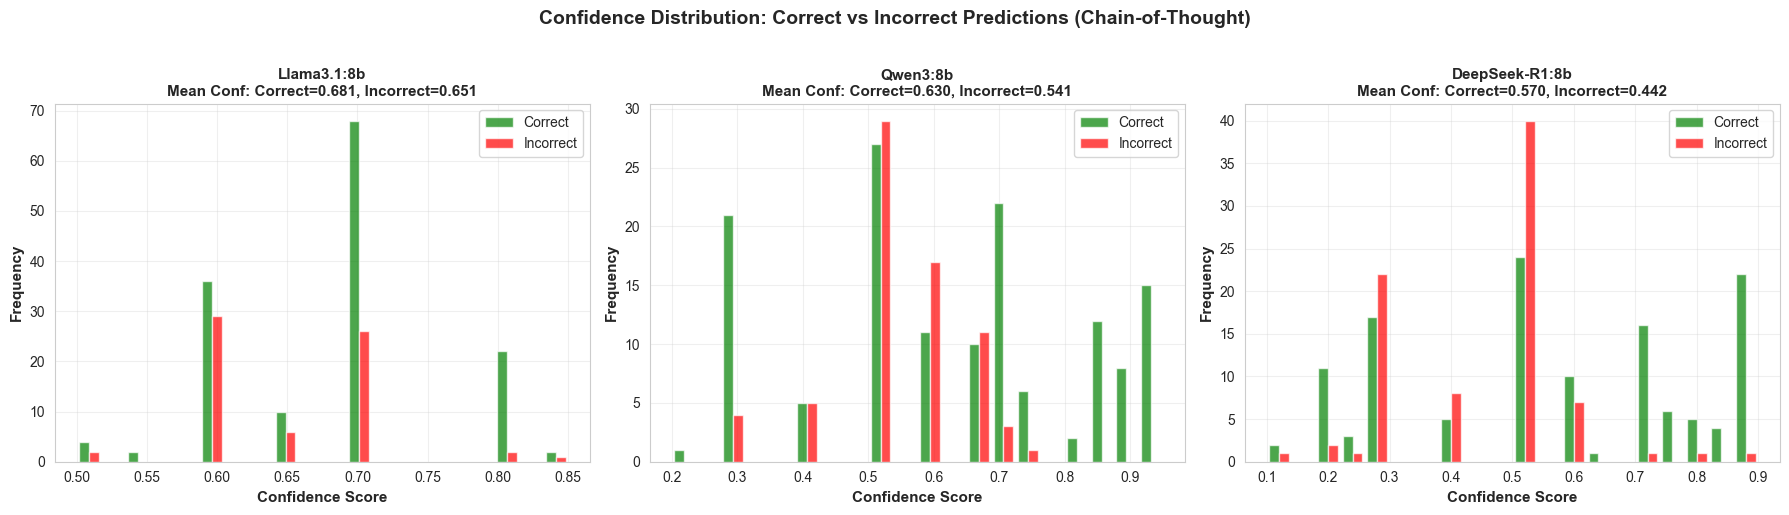


CONFIDENCE CALIBRATION ANALYSIS

I10: Llama3.1:8b:
  Average Confidence (Correct): 0.6812
  Average Confidence (Incorrect): 0.6508
  Calibration Gap: 0.0305
  Total Correct: 144 / 210

  Confidence by Predicted Class:
    Positive: 0.6831 (n=59)
    Negative: 0.7110 (n=86)
    Neutral: 0.6092 (n=65)

I11: Qwen3:8b:
  Average Confidence (Correct): 0.6304
  Average Confidence (Incorrect): 0.5414
  Calibration Gap: 0.0889
  Total Correct: 140 / 210

  Confidence by Predicted Class:
    Positive: 0.7206 (n=17)
    Negative: 0.7821 (n=70)
    Neutral: 0.4809 (n=123)

I12: DeepSeek-R1:8b:
  Average Confidence (Correct): 0.5698
  Average Confidence (Incorrect): 0.4423
  Calibration Gap: 0.1276
  Total Correct: 126 / 210

  Confidence by Predicted Class:
    Positive: 0.6333 (n=3)
    Negative: 0.7730 (n=63)
    Neutral: 0.4052 (n=144)


In [24]:
# Confidence Analysis
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (df_result, title) in enumerate(
    [(i10_valid, "Llama3.1:8b"), (i11_valid, "Qwen3:8b"), (i12_valid, "DeepSeek-R1:8b")]
):
    df_result["correct"] = (
        df_result["true_insight"] == df_result["predicted_insight"]
    )

    correct_conf = df_result[df_result["correct"]]["confidence"]
    incorrect_conf = df_result[~df_result["correct"]]["confidence"]

    axes[idx].hist(
        [correct_conf, incorrect_conf],
        bins=20,
        label=["Correct", "Incorrect"],
        alpha=0.7,
        color=["green", "red"],
    )
    axes[idx].set_xlabel("Confidence Score", fontsize=11, weight="bold")
    axes[idx].set_ylabel("Frequency", fontsize=11, weight="bold")
    axes[idx].set_title(
        f"{title}\nMean Conf: Correct={correct_conf.mean():.3f}, Incorrect={incorrect_conf.mean():.3f}",
        fontsize=11,
        weight="bold",
    )
    axes[idx].legend()
    axes[idx].grid(alpha=0.3)

plt.suptitle(
    "Confidence Distribution: Correct vs Incorrect Predictions (Chain-of-Thought)",
    fontsize=14,
    weight="bold",
    y=1.02,
)
plt.tight_layout()
plt.savefig("tot_confidence_analysis.png", dpi=300, bbox_inches="tight")
plt.show()

print("\n" + "=" * 80)
print("CONFIDENCE CALIBRATION ANALYSIS")
print("=" * 80)
for df_result, exp_name in [
    (i10_valid, "I10: Llama3.1:8b"),
    (i11_valid, "I11: Qwen3:8b"),
    (i12_valid, "I12: DeepSeek-R1:8b"),
]:
    df_result["correct"] = (
        df_result["true_insight"] == df_result["predicted_insight"]
    )

    avg_conf_correct = df_result[df_result["correct"]]["confidence"].mean()
    avg_conf_incorrect = df_result[~df_result["correct"]]["confidence"].mean()
    calibration_gap = avg_conf_correct - avg_conf_incorrect

    print(f"\n{exp_name}:")
    print(f"  Average Confidence (Correct): {avg_conf_correct:.4f}")
    print(f"  Average Confidence (Incorrect): {avg_conf_incorrect:.4f}")
    print(f"  Calibration Gap: {calibration_gap:.4f}")
    print(f"  Total Correct: {df_result['correct'].sum()} / {len(df_result)}")

    # Confidence by insight class
    print(f"\n  Confidence by Predicted Class:")
    for insight in ["positive", "negative", "neutral"]:
        class_df = df_result[df_result["predicted_insight"] == insight]
        if len(class_df) > 0:
            print(
                f"    {insight.capitalize()}: {class_df['confidence'].mean():.4f} (n={len(class_df)})"
            )

## 11. Classification Reports with Per-Class Metrics

In [25]:
# Detailed Classification Reports
print("\n" + "=" * 80)
print("DETAILED CLASSIFICATION REPORTS")
print("=" * 80)

for df_result, exp_name in [
    (i10_valid, "I10: Llama3.1:8b"),
    (i11_valid, "I11: Qwen3:8b"),
    (i12_valid, "I12: DeepSeek-R1:8b"),
]:
    print("\n" + "=" * 80)
    print(f"{exp_name}")
    print("=" * 80)
    print(
        classification_report(
            df_result["true_insight"],
            df_result["predicted_insight"],
            labels=["positive", "negative", "neutral"],
            target_names=["Positive", "Negative", "Neutral"],
        )
    )

# Class-wise Metrics Summary Table
print("\n" + "=" * 80)
print("CLASS-WISE METRICS SUMMARY")
print("=" * 80)

summary_data = []
for metrics, model in [
    (i10_metrics, "Llama3.1:8b"),
    (i11_metrics, "Qwen3:8b"),
    (i12_metrics, "DeepSeek-R1:8b"),
]:
    summary_data.append(
        {
            "Model": model,
            "Pos_P": metrics["Positive_Precision"],
            "Pos_R": metrics["Positive_Recall"],
            "Pos_F1": metrics["Positive_F1"],
            "Neg_P": metrics["Negative_Precision"],
            "Neg_R": metrics["Negative_Recall"],
            "Neg_F1": metrics["Negative_F1"],
            "Neu_P": metrics["Neutral_Precision"],
            "Neu_R": metrics["Neutral_Recall"],
            "Neu_F1": metrics["Neutral_F1"],
        }
    )

summary_df = pd.DataFrame(summary_data)
print("\nPer-Class Metrics (P=Precision, R=Recall, F1=F1-Score):")
display(summary_df.round(4))


DETAILED CLASSIFICATION REPORTS

I10: Llama3.1:8b
              precision    recall  f1-score   support

    Positive       0.81      0.69      0.74        70
    Negative       0.70      0.86      0.77        70
     Neutral       0.55      0.51      0.53        70

    accuracy                           0.69       210
   macro avg       0.69      0.69      0.68       210
weighted avg       0.69      0.69      0.68       210


I11: Qwen3:8b
              precision    recall  f1-score   support

    Positive       0.82      0.20      0.32        70
    Negative       0.91      0.91      0.91        70
     Neutral       0.50      0.89      0.64        70

    accuracy                           0.67       210
   macro avg       0.75      0.67      0.63       210
weighted avg       0.75      0.67      0.63       210


I12: DeepSeek-R1:8b
              precision    recall  f1-score   support

    Positive       1.00      0.04      0.08        70
    Negative       0.92      0.83      0.8

,Model,Pos_P,Pos_R,Pos_F1,Neg_P,Neg_R,Neg_F1,Neu_P,Neu_R,Neu_F1
0,Llama3.1:8b,0.8136,0.6857,0.7442,0.6977,0.8571,0.7692,0.5538,0.5143,0.5333
1,Qwen3:8b,0.8235,0.2000,0.3218,0.9143,0.9143,0.9143,0.5041,0.8857,0.6425
2,DeepSeek-R1:8b,1.0000,0.0429,0.0822,0.9206,0.8286,0.8722,0.4514,0.9286,0.6075


## 12. ToT vs CoT vs Few-Shot vs Zero-Shot Comparison

In [29]:
import glob
# Load previous approach metrics for comparison
try:
    # Find the most recent metrics files
    zero_shot_files = sorted(glob.glob("../Zero_Shot/zero_shot_metrics_summary_*.csv"))
    few_shot_files = sorted(glob.glob("../Few_Shot/few_shot_insight_metrics_summary_*.csv"))
    cot_files = sorted(glob.glob("../Chain_of_Thought/cot_insight_metrics_summary_*.csv"))

    zero_shot_metrics = pd.read_csv(zero_shot_files[-1]) if zero_shot_files else None
    few_shot_metrics = pd.read_csv(few_shot_files[-1]) if few_shot_files else None
    cot_metrics = pd.read_csv(cot_files[-1]) if cot_files else None

    if zero_shot_metrics is not None:
        print(f"✓ Loaded Zero-Shot metrics from: {zero_shot_files[-1]}")
    if few_shot_metrics is not None:
        print(f"✓ Loaded Few-Shot metrics from: {few_shot_files[-1]}")
    if cot_metrics is not None:
        print(f"✓ Loaded CoT metrics from: {cot_files[-1]}")

except Exception as e:
    print(f"⚠️ Could not load comparison metrics: {e}")
    zero_shot_metrics = None
    few_shot_metrics = None
    cot_metrics = None

✓ Loaded Zero-Shot metrics from: ../Zero_Shot/zero_shot_metrics_summary_20260226_122741.csv
✓ Loaded Few-Shot metrics from: ../Few_Shot/few_shot_insight_metrics_summary_20260226_190604.csv
✓ Loaded CoT metrics from: ../Chain_of_Thought/cot_insight_metrics_summary_20260226_234505.csv



CROSS-APPROACH COMPARISON: Zero-Shot vs Few-Shot vs CoT vs ToT


,Approach,Experiment,Total Samples,Valid Predictions,Accuracy,Macro-F1,Weighted-F1,Macro-Precision,Macro-Recall,MCC,Positive_Precision,Positive_Recall,Positive_F1,Negative_Precision,Negative_Recall,Negative_F1,Neutral_Precision,Neutral_Recall,Neutral_F1
0,Zero-Shot,I1: Llama3.1:8b,210,210,0.9000,0.8952,0.8952,0.9149,0.9000,0.8603,0.8235,1.0000,0.9032,0.9211,1.0000,0.9589,1.0000,0.7000,0.8235
1,Zero-Shot,I2: Qwen3:8b,210,210,0.9143,0.9153,0.9153,0.9284,0.9143,0.8777,0.9828,0.8143,0.8906,1.0000,0.9429,0.9706,0.8023,0.9857,0.8846
2,Zero-Shot,I3: DeepSeek-R1:8b,208,208,0.9231,0.9238,0.9237,0.9268,0.9230,0.8857,0.9385,0.8841,0.9104,0.9848,0.9420,0.9630,0.8571,0.9429,0.8980
3,Few-Shot,I4: Llama3.1:8b (Few-Shot),210,210,0.8381,0.8243,0.8243,0.8639,0.8381,0.7770,0.8395,0.9714,0.9007,0.7778,1.0000,0.8750,0.9744,0.5429,0.6972
4,Few-Shot,I5: Qwen3:8b (Few-Shot),210,210,0.9524,0.9529,0.9529,0.9551,0.9524,0.9295,0.9706,0.9429,0.9565,1.0000,0.9429,0.9706,0.8947,0.9714,0.9315
5,Few-Shot,I6: DeepSeek-R1:8b (Few-Shot),210,210,0.9333,0.9340,0.9340,0.9360,0.9333,0.9006,0.9296,0.9429,0.9362,1.0000,0.9286,0.9630,0.8784,0.9286,0.9028
6,Chain-of-Thought,I7: Llama3.1:8b (COT),210,208,0.8462,0.8391,0.8401,0.8749,0.8438,0.7868,0.9420,0.9286,0.9353,0.7292,1.0000,0.8434,0.9535,0.6029,0.7387
7,Chain-of-Thought,I8: Qwen3:8b (COT),210,210,0.9000,0.9020,0.9020,0.9161,0.9000,0.8564,0.9667,0.8286,0.8923,1.0000,0.9000,0.9474,0.7816,0.9714,0.8662
8,Chain-of-Thought,I9: DeepSeek-R1:8b (COT),210,209,0.9091,0.9082,0.9085,0.9097,0.9087,0.8645,0.8667,0.9286,0.8966,0.9577,0.9714,0.9645,0.9048,0.8261,0.8636
9,Tree-of-Thought,I10: Llama3.1:8b (ToT),210,210,0.6857,0.6823,0.6823,0.6884,0.6857,0.5322,0.8136,0.6857,0.7442,0.6977,0.8571,0.7692,0.5538,0.5143,0.5333



✓ Full comparison table saved as: all_approaches_comparison_20260227_065230.csv

AVERAGE PERFORMANCE BY APPROACH


,Accuracy,Macro-F1,MCC
Approach,,,
Chain-of-Thought,0.8851,0.8831,0.8359
Few-Shot,0.9079,0.9037,0.8690
Tree-of-Thought,0.6508,0.6097,0.5269
Zero-Shot,0.9125,0.9114,0.8746


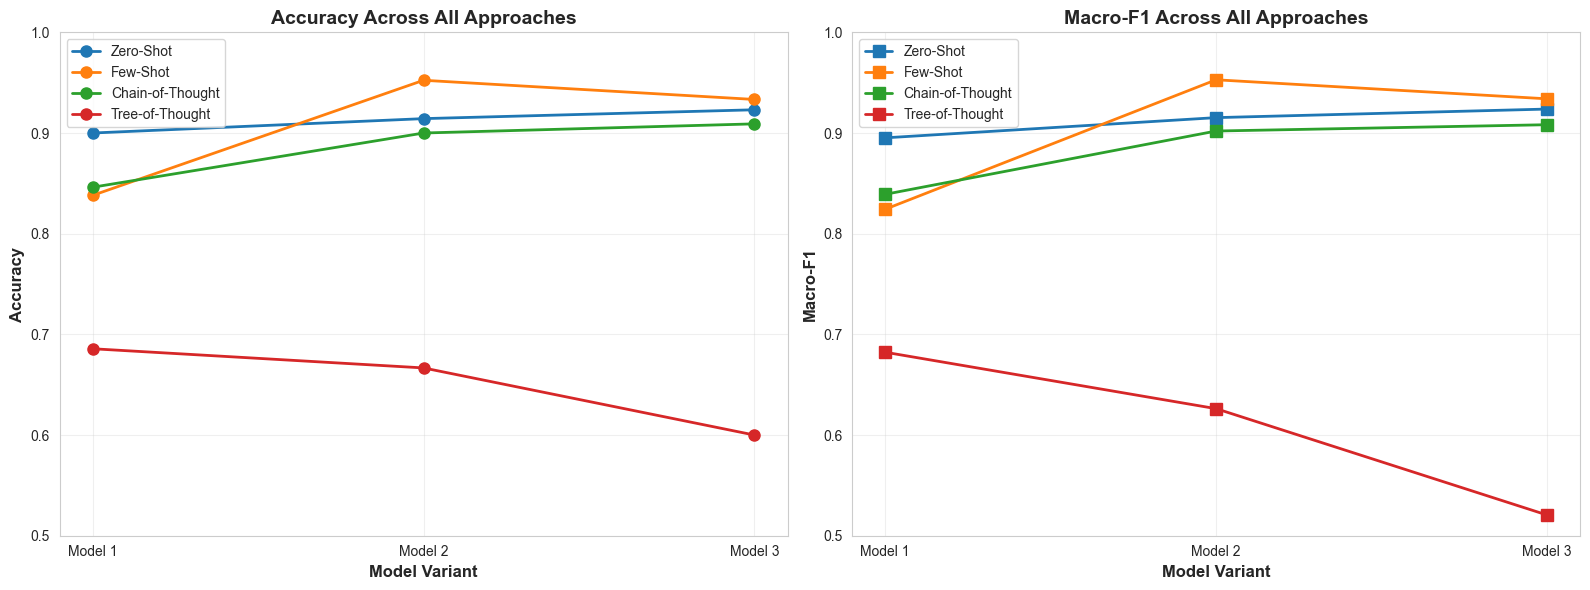

✓ Complete approach comparison visualization saved


In [30]:
# Compare all four approaches
if all(m is not None for m in [zero_shot_metrics, few_shot_metrics, cot_metrics]):
    all_approaches = pd.concat(
        [
            zero_shot_metrics.assign(Approach="Zero-Shot"),
            few_shot_metrics.assign(Approach="Few-Shot"),
            cot_metrics.assign(Approach="Chain-of-Thought"),
            metrics_df.assign(Approach="Tree-of-Thought"),
        ],
        ignore_index=True,
    )

    print("\n" + "=" * 80)
    print("CROSS-APPROACH COMPARISON: Zero-Shot vs Few-Shot vs CoT vs ToT")
    print("=" * 80)

    
    comparison_cols = ["Approach", "Experiment", "Accuracy", "Macro-F1", "MCC"]
    if all(col in all_approaches.columns for col in comparison_cols):
        display(all_approaches[['Approach', 'Experiment', 'Total Samples', 'Valid Predictions', 'Accuracy',
       'Macro-F1', 'Weighted-F1', 'Macro-Precision', 'Macro-Recall', 'MCC',
       'Positive_Precision', 'Positive_Recall', 'Positive_F1',
       'Negative_Precision', 'Negative_Recall', 'Negative_F1',
       'Neutral_Precision', 'Neutral_Recall', 'Neutral_F1']].round(4))
        #save to csv
        all_approaches.to_csv(f"all_approaches_comparison_{timestamp}.csv", index=False)
        print(f"\n✓ Full comparison table saved as: all_approaches_comparison_{timestamp}.csv")
    else:
        display(
            all_approaches[['Approach', 'Experiment', 'Total Samples', 'Valid Predictions', 'Accuracy',
       'Macro-F1', 'Weighted-F1', 'Macro-Precision', 'Macro-Recall', 'MCC',
       'Positive_Precision', 'Positive_Recall', 'Positive_F1',
       'Negative_Precision', 'Negative_Recall', 'Negative_F1',
       'Neutral_Precision', 'Neutral_Recall', 'Neutral_F1' ]].round(4))
       #save to csv
        all_approaches.to_csv(f"all_approaches_comparison_{timestamp}.csv", index=False)
        print(f"\n✓ Full comparison table saved as: all_approaches_comparison_{timestamp}.csv")
        

    print("\n" + "=" * 80)
    print("AVERAGE PERFORMANCE BY APPROACH")
    print("=" * 80)

    approach_avg = all_approaches.groupby("Approach")[["Accuracy", "Macro-F1"]].mean()
    if "MCC" in all_approaches.columns:
        approach_avg["MCC"] = all_approaches.groupby("Approach")["MCC"].mean()

    display(approach_avg.round(4))

    # Visualize approach progression
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    for approach in ["Zero-Shot", "Few-Shot", "Chain-of-Thought", "Tree-of-Thought"]:
        approach_data = all_approaches[all_approaches["Approach"] == approach]
        axes[0].plot(
            range(len(approach_data)),
            approach_data["Accuracy"],
            marker="o",
            label=approach,
            linewidth=2,
            markersize=8,
        )

    axes[0].set_xlabel("Model Variant", fontsize=12, weight="bold")
    axes[0].set_ylabel("Accuracy", fontsize=12, weight="bold")
    axes[0].set_title("Accuracy Across All Approaches", fontsize=14, weight="bold")
    axes[0].set_xticks(range(3))
    axes[0].set_xticklabels(["Model 1", "Model 2", "Model 3"])
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    axes[0].set_ylim([0.5, 1.0])

    for approach in ["Zero-Shot", "Few-Shot", "Chain-of-Thought", "Tree-of-Thought"]:
        approach_data = all_approaches[all_approaches["Approach"] == approach]
        axes[1].plot(
            range(len(approach_data)),
            approach_data["Macro-F1"],
            marker="s",
            label=approach,
            linewidth=2,
            markersize=8,
        )

    axes[1].set_xlabel("Model Variant", fontsize=12, weight="bold")
    axes[1].set_ylabel("Macro-F1", fontsize=12, weight="bold")
    axes[1].set_title("Macro-F1 Across All Approaches", fontsize=14, weight="bold")
    axes[1].set_xticks(range(3))
    axes[1].set_xticklabels(["Model 1", "Model 2", "Model 3"])
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    axes[1].set_ylim([0.5, 1.0])

    plt.tight_layout()
    plt.savefig(
        "all_approaches_comparison_insight_assessment.png", dpi=300, bbox_inches="tight"
    )
    plt.show()

    print("✓ Complete approach comparison visualization saved")
else:
    print("\n⚠️ Cannot perform full comparison - missing baseline metrics")
    print(
        "   Please run Zero-Shot (R1-R3), Few-Shot (R4-R6), and CoT (R7-R9) experiments first"
    )